In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib import font_manager

In [26]:
lfi_methods = ["lmdi_plus", "lime", "shap", "lmdi_sutera"]

In [27]:
pves = [0.1]
rhos = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99]
mean_results = {}
sd_results = {}
for method in lfi_methods:
    group_results = {}
    sd_group_results = {}
    sig_mat = np.zeros((len(pves), len(rhos)))
    c_nsig_mat = np.zeros((len(pves), len(rhos)))
    nsig_mat = np.zeros((len(pves), len(rhos)))
    sig_sd = np.zeros((len(pves), len(rhos)))
    c_nsig_sd = np.zeros((len(pves), len(rhos)))
    nsig_sd = np.zeros((len(pves), len(rhos)))
    for pve_idx in range(len(pves)):
        for rho_idx in range(len(rhos)):
            rankings = np.zeros((250, 100, 50)) # 250 samples, 100 features, 50 seeds
            for seed in range(1, 51):
                rankings[:, :, seed-1] = pd.read_csv(f"results/pve{pves[pve_idx]}/rho{rhos[rho_idx]}/seed{seed}/rf/rankings/{method}.csv").to_numpy()
            sds = np.std(np.mean(rankings, axis = 0), axis=1)/math.sqrt(rankings.shape[0])
            sig_mat[pve_idx, rho_idx] = np.mean(rankings[:, :6])
            sig_sd[pve_idx, rho_idx] = np.mean(sds[:6])
            # average features 7-50 in rankings
            c_nsig_mat[pve_idx, rho_idx] = np.mean(rankings[:, 6:50])
            c_nsig_sd[pve_idx, rho_idx] = np.mean(sds[6:50])
            # average features 51-100 in rankings
            nsig_mat[pve_idx, rho_idx] = np.mean(rankings[:, 50:])
            nsig_sd[pve_idx, rho_idx] = np.mean(sds[50:])
    group_results['sig'] = sig_mat
    group_results['c_nsig'] = c_nsig_mat
    group_results['nsig'] = nsig_mat
    sd_group_results['sig'] = sig_sd
    sd_group_results['c_nsig'] = c_nsig_sd
    sd_group_results['nsig'] = nsig_sd
    sd_results[method] = sd_group_results
    mean_results[method] = group_results

--------------------------


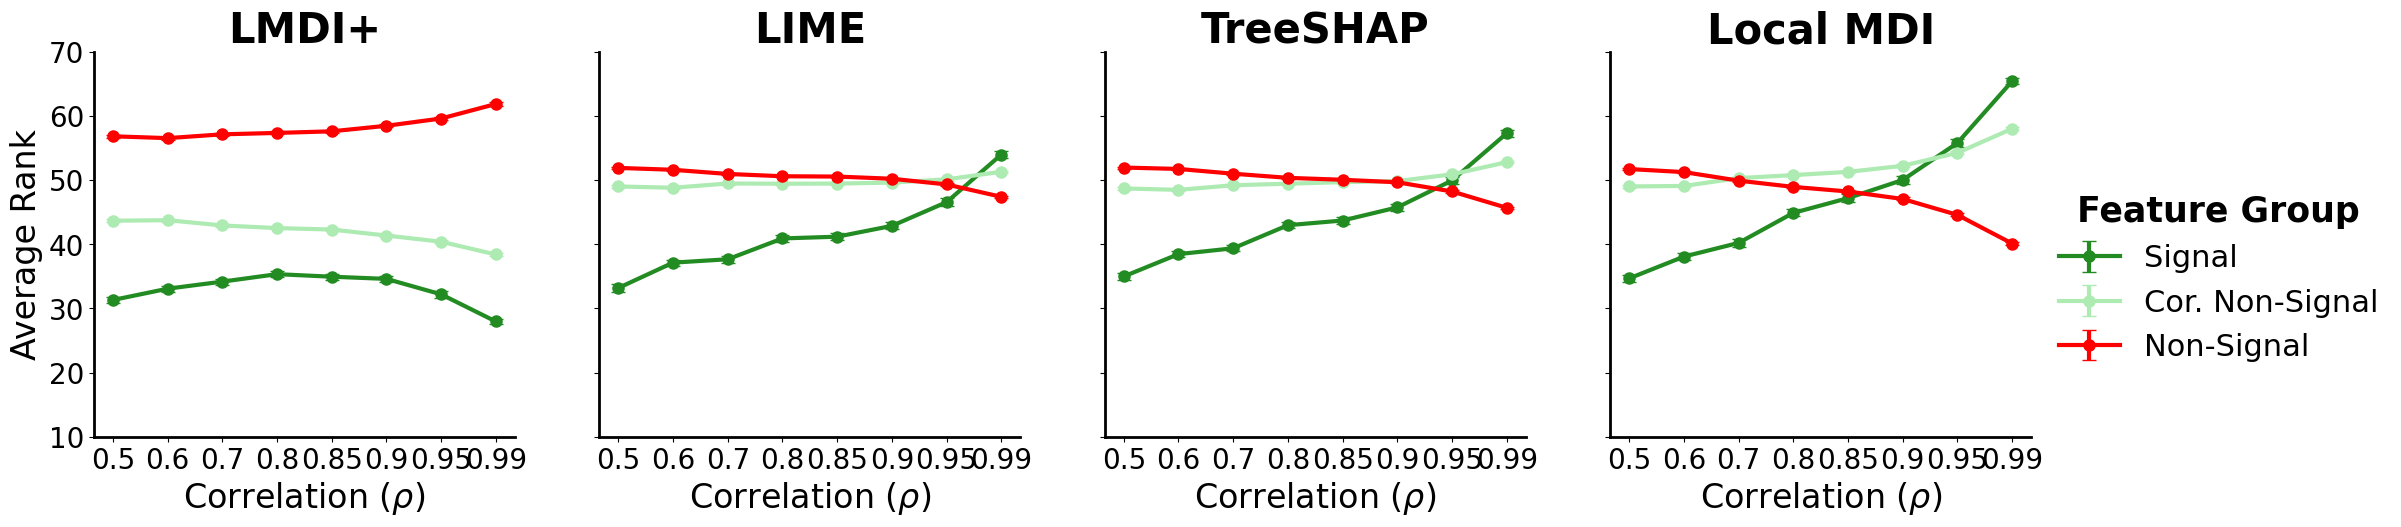

In [28]:
titles = {'shap': 'TreeSHAP', 'lime': 'LIME', 'lmdi_sutera': 'Local MDI',
          'lmdi_plus': 'LMDI+'}
rf_plots = []
for pve_idx in range(len([1])):
    print("--------------------------")
    fig, axs = plt.subplots(1, len(lfi_methods), sharey=True, figsize=(25, 5))
    # if pves[pve_idx] == 0.1:
    #     plt.ylim(30, 70)
    # else:
    #     plt.ylim(10, 70)
    plt.ylim(10, 70)
    for method_idx in range(len(lfi_methods)):
        # plot results, where each group is a separate line on the plot
        plt.rcParams['axes.labelsize'] = 30
        plt.rcParams['xtick.labelsize'] = 10
        plt.rcParams['ytick.labelsize'] = 12
        plt.rcParams['axes.spines.right'] = False
        plt.rcParams['axes.spines.top'] = False
        # plt.rcParams['axes.edgecolor'] = 'lightgrey'
        plt.rcParams['axes.edgecolor'] = 'black'
        plt.rcParams['axes.linewidth'] = 2.0
        axs[method_idx].errorbar(range(len(rhos)), mean_results[lfi_methods[method_idx]]['sig'][pve_idx, :],
                 yerr=sd_results[lfi_methods[method_idx]]['sig'][pve_idx, :],
                 fmt='o', color='forestgreen', label='Signal', capsize=5,
                 linestyle='solid', linewidth=3, markersize=8)
        axs[method_idx].errorbar(range(len(rhos)), mean_results[lfi_methods[method_idx]]['c_nsig'][pve_idx, :],
                 yerr=sd_results[lfi_methods[method_idx]]['c_nsig'][pve_idx, :],
                 fmt='o', color='#ADEBB3', label='Cor. Non-Signal', capsize=5,
                 linestyle='solid', linewidth=3, markersize=8)
        axs[method_idx].errorbar(range(len(rhos)), mean_results[lfi_methods[method_idx]]['nsig'][pve_idx, :],
                 yerr=sd_results[lfi_methods[method_idx]]['nsig'][pve_idx, :],
                 fmt='o', color='red', label='Non-Signal', capsize=5,
                 linestyle='solid', linewidth=3, markersize=8)
        # axs[method_idx].plot(mean_results[lfi_methods[method_idx]]['sig'][pve_idx, :], marker = "o",
        #          label="Signal", color='forestgreen')
        # axs[method_idx].fill_between(range(len(rhos)),
        #                  mean_results[lfi_methods[method_idx]]['sig'][pve_idx, :] - \
        #                      sd_results[lfi_methods[method_idx]]['sig'][pve_idx, :],
        #                      mean_results[lfi_methods[method_idx]]['sig'][pve_idx, :] + \
        #                          sd_results[lfi_methods[method_idx]]['sig'][pve_idx, :],
        #                          color='forestgreen', alpha=0.3)
        # axs[method_idx].plot(mean_results[lfi_methods[method_idx]]['c_nsig'][pve_idx, :], marker = "o",
        #          label="Cor. Non-Signal", color='#ADEBB3')
        # axs[method_idx].fill_between(range(len(rhos)),
        #                  mean_results[lfi_methods[method_idx]]['c_nsig'][pve_idx, :] - \
        #                      sd_results[lfi_methods[method_idx]]['c_nsig'][pve_idx, :],
        #                      mean_results[lfi_methods[method_idx]]['c_nsig'][pve_idx, :] + \
        #                          sd_results[lfi_methods[method_idx]]['c_nsig'][pve_idx, :],
        #                          color='#ADEBB3', alpha=0.3)
        # axs[method_idx].plot(mean_results[lfi_methods[method_idx]]['nsig'][pve_idx, :], marker = "o",
        #          label="Non-Signal", color='red')
        # axs[method_idx].fill_between(range(len(rhos)),
        #                  mean_results[lfi_methods[method_idx]]['nsig'][pve_idx, :] - \
        #                      sd_results[lfi_methods[method_idx]]['nsig'][pve_idx, :],
        #                      mean_results[lfi_methods[method_idx]]['nsig'][pve_idx, :] + \
        #                          sd_results[lfi_methods[method_idx]]['nsig'][pve_idx, :],
        #                          color = 'red', alpha=0.3)
        axs[method_idx].set_xlabel(r'Correlation ($\rho$)', fontsize=24)
        # x-axis ticks should be rho values
        axs[method_idx].set_xticks(range(len(rhos)), rhos)
        # make xaxis label big
        axs[method_idx].tick_params(axis='both', labelsize=20)
        
        # set y-axis ticks at 30, 40, 50, 60, 70
        # if pves[pve_idx] == 0.1:
        #     axs[method_idx].set_yticks([30, 40, 50, 60, 70])
        # else:
        #     axs[method_idx].set_yticks([10, 20, 30, 40, 50, 60, 70])
        axs[method_idx].set_yticks([10, 20, 30, 40, 50, 60, 70])
        # y-axis label should be Average Ranking
        if method_idx == 0:
            axs[method_idx].set_ylabel("Average Rank", fontsize=24)
        axs[method_idx].set_title(titles[lfi_methods[method_idx]], fontsize=30, fontweight='bold')
    title_font_properties = font_manager.FontProperties(weight='bold', size=25)
    plt.legend(title = "Feature Group", loc = "upper left", bbox_to_anchor=(1,0.7),
               fontsize=22, title_fontproperties = title_font_properties, frameon=False)
    # fig.text(0.06, 0.5, "RF Model", ha='center', va='center', rotation=90, fontsize=24, fontstyle='italic', fontweight='bold')
    rf_plots.append(plt.gcf())
    # plt.savefig("images/bigger/correlation.png", format='png', bbox_inches='tight')
    plt.savefig("images/correlation.pdf", format='pdf', bbox_inches='tight')
    plt.show()

In [30]:
mean_results

{'lmdi_plus': {'sig': array([[31.30545333, 33.06841333, 34.17081333, 35.33341333, 34.93776   ,
          34.59658667, 32.18998667, 27.957     ]]),
  'c_nsig': array([[43.66361091, 43.74722   , 42.92256364, 42.51714727, 42.28619455,
          41.35213818, 40.39150545, 38.39876545]]),
  'nsig': array([[56.819368 , 56.5342368, 57.1276464, 57.3449008, 57.5956176,
          58.458528 , 59.5926768, 61.8542464]])},
 'lime': {'sig': array([[33.18418667, 37.13074667, 37.65610667, 40.9034    , 41.17329333,
          42.85853333, 46.55582667, 53.96908   ]]),
  'c_nsig': array([[49.00328909, 48.80124909, 49.46589091, 49.42953818, 49.44870909,
          49.60577091, 50.10811273, 51.28958727]]),
  'nsig': array([[51.8950032, 51.5992112, 50.9512832, 50.5935984, 50.5443408,
          50.2038976, 49.3181616, 47.3888736]])},
 'shap': {'sig': array([[34.98088   , 38.45676   , 39.36809333, 42.96508   , 43.69464   ,
          45.73870667, 49.93156   , 57.28016   ]]),
  'c_nsig': array([[48.69641273, 48.470

In [31]:
from IPython.display import Markdown

rhos = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99]
titles = {'shap': 'TreeSHAP', 'lime': 'LIME', 'lmdi_sutera': 'Local MDI', 'lmdi_plus': 'LMDI+'}
group_labels = {'sig': 'Signal', 'c_nsig': 'Cor. Non-Signal', 'nsig': 'Non-Signal'}

header = "| Method | Feature Group | " + " | ".join([f"ρ={r}" for r in rhos]) + " |"
separator = "|--------|---------------|" + "|".join(["--------:" for _ in rhos]) + "|"

rows = [header, separator]

for method in mean_results:
    for group in ['sig', 'c_nsig', 'nsig']:
        values = mean_results[method][group][0, :]  # pve_idx = 0
        row = f"| {titles[method]} | {group_labels[group]} | " + " | ".join([f"{v:.2f}" for v in values]) + " |"
        rows.append(row)
    # Add a visual separator between methods
    rows.append("|  |  | " + " | ".join(["" for _ in rhos]) + " |")

md_table = "\n".join(rows)
display(Markdown(md_table))

| Method | Feature Group | ρ=0.5 | ρ=0.6 | ρ=0.7 | ρ=0.8 | ρ=0.85 | ρ=0.9 | ρ=0.95 | ρ=0.99 |
|--------|---------------|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|
| LMDI+ | Signal | 31.31 | 33.07 | 34.17 | 35.33 | 34.94 | 34.60 | 32.19 | 27.96 |
| LMDI+ | Cor. Non-Signal | 43.66 | 43.75 | 42.92 | 42.52 | 42.29 | 41.35 | 40.39 | 38.40 |
| LMDI+ | Non-Signal | 56.82 | 56.53 | 57.13 | 57.34 | 57.60 | 58.46 | 59.59 | 61.85 |
|  |  |  |  |  |  |  |  |  |  |
| LIME | Signal | 33.18 | 37.13 | 37.66 | 40.90 | 41.17 | 42.86 | 46.56 | 53.97 |
| LIME | Cor. Non-Signal | 49.00 | 48.80 | 49.47 | 49.43 | 49.45 | 49.61 | 50.11 | 51.29 |
| LIME | Non-Signal | 51.90 | 51.60 | 50.95 | 50.59 | 50.54 | 50.20 | 49.32 | 47.39 |
|  |  |  |  |  |  |  |  |  |  |
| TreeSHAP | Signal | 34.98 | 38.46 | 39.37 | 42.97 | 43.69 | 45.74 | 49.93 | 57.28 |
| TreeSHAP | Cor. Non-Signal | 48.70 | 48.47 | 49.19 | 49.43 | 49.67 | 49.84 | 50.89 | 52.78 |
| TreeSHAP | Non-Signal | 51.95 | 51.73 | 50.99 | 50.35 | 50.04 | 49.65 | 48.22 | 45.68 |
|  |  |  |  |  |  |  |  |  |  |
| Local MDI | Signal | 34.68 | 38.07 | 40.21 | 44.88 | 47.18 | 50.01 | 55.78 | 65.41 |
| Local MDI | Cor. Non-Signal | 49.00 | 49.08 | 50.30 | 50.77 | 51.27 | 52.22 | 54.25 | 58.00 |
| Local MDI | Non-Signal | 51.72 | 51.24 | 49.91 | 48.93 | 48.22 | 47.05 | 44.57 | 40.11 |
|  |  |  |  |  |  |  |  |  |  |

In [33]:
rows

['| Method | Feature Group | ρ=0.5 | ρ=0.6 | ρ=0.7 | ρ=0.8 | ρ=0.85 | ρ=0.9 | ρ=0.95 | ρ=0.99 |',
 '|--------|---------------|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|',
 '| LMDI+ | Signal | 31.31 | 33.07 | 34.17 | 35.33 | 34.94 | 34.60 | 32.19 | 27.96 |',
 '| LMDI+ | Cor. Non-Signal | 43.66 | 43.75 | 42.92 | 42.52 | 42.29 | 41.35 | 40.39 | 38.40 |',
 '| LMDI+ | Non-Signal | 56.82 | 56.53 | 57.13 | 57.34 | 57.60 | 58.46 | 59.59 | 61.85 |',
 '|  |  |  |  |  |  |  |  |  |  |',
 '| LIME | Signal | 33.18 | 37.13 | 37.66 | 40.90 | 41.17 | 42.86 | 46.56 | 53.97 |',
 '| LIME | Cor. Non-Signal | 49.00 | 48.80 | 49.47 | 49.43 | 49.45 | 49.61 | 50.11 | 51.29 |',
 '| LIME | Non-Signal | 51.90 | 51.60 | 50.95 | 50.59 | 50.54 | 50.20 | 49.32 | 47.39 |',
 '|  |  |  |  |  |  |  |  |  |  |',
 '| TreeSHAP | Signal | 34.98 | 38.46 | 39.37 | 42.97 | 43.69 | 45.74 | 49.93 | 57.28 |',
 '| TreeSHAP | Cor. Non-Signal | 48.70 | 48.47 | 49.19 | 49.43 | 49.67 | 49.84 | 50.